In [23]:
# cell section - imports only
import numpy as np, pandas as pd, matplotlib.pyplot as plt, mlflow
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
# load + split + standardize
data = fetch_california_housing(as_frame=True)
#print(data.DESCR)

X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scalar = StandardScaler().fit(X_train)

X_train_scaled = scalar.transform(X_train)
X_test_scaled = scalar.transform(X_test)




In [25]:
# mlflow setting experiment
mlflow.set_experiment("regularization")

<Experiment: artifact_location='file:d:/ai-engineering-journey/daily-notebooks/week-02/mlruns/1', creation_time=1778079756003, experiment_id='1', last_update_time=1778079756003, lifecycle_stage='active', name='regularization', tags={}, trace_location=None, workspace='default'>

In [26]:
# mlflow run linear_regression
linear_regression_coef = 0
with mlflow.start_run(run_name='linear_regression'):
    mlflow.log_param('n_features', X_train.shape[1])
    mlflow.log_param('model_type', 'Linear regression')

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)

    train_mse = mean_squared_error(y_true=y_train, y_pred=y_train_pred)
    train_r2score = r2_score(y_true=y_train, y_pred=y_train_pred)

    mlflow.log_metric('train_mse', train_mse)
    mlflow.log_metric('train_r2score', train_r2score)

    y_test_pred = model.predict(X_test_scaled)

    test_mse = mean_squared_error(y_true=y_test, y_pred=y_test_pred)
    test_r2score = r2_score(y_true=y_test, y_pred=y_test_pred)

    mlflow.log_metric('test_mse', test_mse)
    mlflow.log_metric('test_r2score', test_r2score)

    linear_regression_coef = model.coef_
    mlflow.sklearn.log_model(model, name='Linear Regression')

2026/05/07 22:00:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/07 22:00:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


In [27]:
# mlflow Ridge Regression
ridge_regression_coef = 0
with mlflow.start_run(run_name='Ridge_regression'):
    mlflow.log_param('n_features', X_train.shape[1])
    mlflow.log_param('model_type', 'Ridge regression')

    model = Ridge(alpha=1.0)
    mlflow.log_param('alpha', 1.0)
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)

    train_mse = mean_squared_error(y_true=y_train, y_pred=y_train_pred)
    train_r2score = r2_score(y_true=y_train, y_pred=y_train_pred)
    
    mlflow.log_metric('train_mse', train_mse)
    mlflow.log_metric('train_r2score', train_r2score)

    y_test_pred = model.predict(X_test_scaled)

    test_mse = mean_squared_error(y_true=y_test, y_pred=y_test_pred)
    test_r2score = r2_score(y_true=y_test, y_pred=y_test_pred)

    mlflow.log_metric('test_mse', test_mse)
    mlflow.log_metric('test_r2score', test_r2score)
    
    ridge_regression_coef = model.coef_
    mlflow.sklearn.log_model(model, name='Ridge regression')

2026/05/07 22:00:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/07 22:00:55 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Yes, the Ridge regression improve the test_mse. 
Linear regression - test_mse : 0.5558916 
Ridge regression - test_mse : 0.5558549 , test_mse improved by 0.0000367

The r2_test is nearly ~0.58, sanity is checked and its matching.

In [28]:
#Lasso regression
lasso_regression_coef = 0
with mlflow.start_run(run_name='Lasso regression'):
    mlflow.log_param('n_features', X_train.shape[1])
    mlflow.log_param('alpha', 0.1)
    mlflow.log_param('model_type', 'Lasso regression model')
    model = Lasso(alpha=0.1)
    model.fit(X=X_train_scaled, y=y_train)

    y_train_pred = model.predict(X=X_train_scaled)
    
    train_mse = mean_squared_error(y_true=y_train, y_pred=y_train_pred)
    train_r2score = r2_score(y_true=y_train, y_pred=y_train_pred)

    mlflow.log_metric('train_mse', train_mse)
    mlflow.log_metric('train_r2score', train_r2score)

    y_test_pred = model.predict(X_test_scaled)

    test_mse = mean_squared_error(y_true=y_test, y_pred=y_test_pred)
    test_r2score = r2_score(y_true=y_test, y_pred=y_test_pred)

    mlflow.log_metric('test_mse', test_mse)
    mlflow.log_metric('test_r2score', test_r2score)

    lasso_regression_coef = model.coef_
    mlflow.sklearn.log_model(model, name='Lasso model')

2026/05/07 22:00:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/07 22:01:01 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


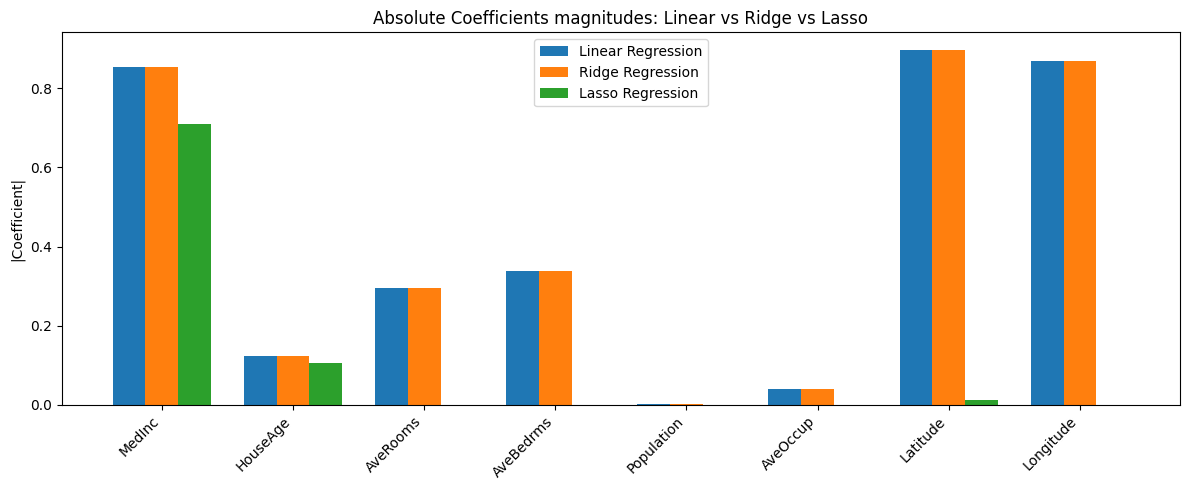

In [29]:
feature_names = data.feature_names
x_pos = np.arange(len(feature_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_pos-width, np.abs(linear_regression_coef), width, label='Linear Regression')
ax.bar(x_pos, np.abs(ridge_regression_coef), width, label='Ridge Regression')
ax.bar(x_pos + width, np.abs(lasso_regression_coef), width, label='Lasso Regression')

ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names, rotation=45, ha='right')
ax.set_ylabel('|Coefficient|')
ax.set_title('Absolute Coefficients magnitudes: Linear vs Ridge vs Lasso')
ax.legend()
plt.tight_layout()
plt.show()

The lasso regression makes features AveRooms, AveBedrms, population, AveOccup, Longitude makes zero. From the Lasso regression, i think there are features which contributes to housing features like AveBedrms or AveRooms (either one should not be zero), It makes sense when population and latitude makes zero it makes sense in predicting housing value